In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [2]:
data_dir = Path("../data/raw")
csv_files = sorted(data_dir.glob("*.csv"))

csv_files

[WindowsPath('../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv'),
 WindowsPath('../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_2.csv'),
 WindowsPath('../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_3.csv')]

In [3]:
cols = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "DepDelay",
    "Cancelled"
]

In [4]:
dfs = []

for file in csv_files:
    df_part = pd.read_csv(file, usecols=cols)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

df.shape

(1598468, 8)

In [5]:
df.head()

,Month,DayOfWeek,Reporting_Airline,Origin,Dest,CRSDepTime,DepDelay,Cancelled
0,1,5,YX,CMH,DCA,1224,-3.0,0.0
1,1,6,YX,CMH,DCA,1224,-10.0,0.0
2,1,7,YX,CMH,DCA,1224,-6.0,0.0
3,1,1,YX,CMH,DCA,1224,-7.0,0.0
4,1,2,YX,CMH,DCA,1224,-6.0,0.0


In [6]:
df = df[df["Cancelled"] == 0].copy()

df = df.dropna(subset=[
    "DepDelay",
    "CRSDepTime",
    "Reporting_Airline",
    "Origin",
    "Dest"
])

df.shape

(1534734, 8)

In [7]:
df = df.sample(n=200_000, random_state=42)
df.shape

(200000, 8)

In [8]:
df["delay_flag"] = (df["DepDelay"] > 15).astype(int)

df[["DepDelay", "delay_flag"]].head(10)

,DepDelay,delay_flag
1520653,-7.0,0
344435,-5.0,0
399849,-8.0,0
210583,-15.0,0
1241754,152.0,1
1512894,-1.0,0
324523,-6.0,0
973753,0.0,0
961953,-6.0,0
665439,-4.0,0


In [9]:
df["CRSDepTime"] = df["CRSDepTime"].astype(int)
df["dep_hour"] = df["CRSDepTime"] // 100

df[["CRSDepTime", "dep_hour"]].head(10)

,CRSDepTime,dep_hour
1520653,1316,13
344435,1415,14
399849,1329,13
210583,1110,11
1241754,2012,20
1512894,1045,10
324523,1955,19
973753,1115,11
961953,1722,17
665439,600,6


In [10]:
features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "dep_hour"
]

X = df[features]
y = df["delay_flag"]

X.head()

,Month,DayOfWeek,Reporting_Airline,Origin,Dest,dep_hour
1520653,3,7,AA,DFW,ABQ,13
344435,1,2,WN,SAN,PHX,14
399849,1,5,YX,JFK,BWI,13
210583,1,4,HA,LAX,KOA,11
1241754,3,4,F9,DEN,ORD,20


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
numeric_features = ["Month", "DayOfWeek", "dep_hour"]
categorical_features = ["Reporting_Airline", "Origin", "Dest"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=50,
        max_depth = 12,
        min_samples_leaf=5,
        random_state=42,
        class_weight= "balanced",
        n_jobs=-1
    ))
])

In [15]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [16]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.63      0.73     32129
           1       0.29      0.60      0.39      7871

    accuracy                           0.63     40000
   macro avg       0.58      0.62      0.56     40000
weighted avg       0.75      0.63      0.66     40000



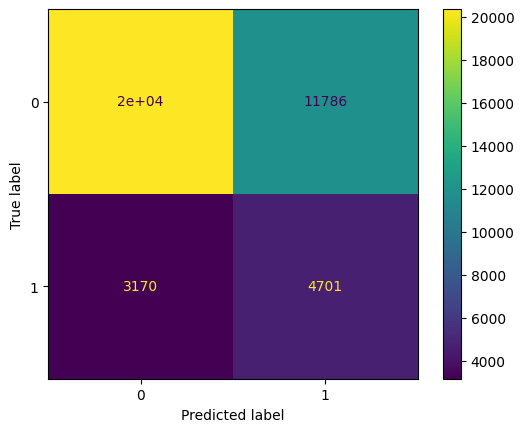

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

In [18]:
df["delay_flag"].value_counts(normalize=True)

delay_flag
0    0.803215
1    0.196785
Name: proportion, dtype: float64